# Idiom Meaning Retrieval with IdiomX

This notebook builds a semantic retrieval system that takes either:

- an idiom itself  
  *Example:* `spill the tea`

or

- a sentence containing an idiom  
  *Example:* `She spilled the tea about the party.`

and retrieves:

- the most likely idiom  
- English meaning  
- Arabic meaning  
- French meaning (when available)  
- contextual explanation  
- example usage  

---

## Notebook Workflow

```text
Load and inspect IdiomX dataset
        ↓
Clean and filter high-quality idiomatic data
        ↓
Build unified retrieval bank
(canonical idioms + example sentences)
        ↓
Generate embeddings and FAISS semantic index
        ↓
Dense retrieval baseline (MiniLM)
        ↓
Hybrid retrieval (MiniLM + BM25 + phrase boost)
        ↓
Cross-encoder reranking
        ↓
Evaluate and compare retrieval performance
        ↓
Prepare reusable artifacts for demo deployment
```

---

## Retrieval Approaches Compared

This notebook evaluates three progressively stronger retrieval methods:

1. **Dense Retrieval Baseline**  
   Sentence embeddings (MiniLM) + FAISS

2. **Hybrid Retrieval**  
   Dense retrieval + BM25 lexical retrieval + phrase-aware boosting

3. **Hybrid + Cross-Encoder Reranking**  
   Candidate reranking using a cross-encoder for improved Top-1 precision

---

## Evaluation

Performance is measured using held-out queries with:

- Top-1 Accuracy  
- Top-3 Accuracy  
- Top-5 Accuracy  
- Mean Reciprocal Rank (MRR)

---

## Final Goal

Produce a reusable multilingual idiom meaning retrieval system that can later be:

- used in a demo notebook / Hugging Face Space  
- integrated with idiom detection (Task 1) for literal-vs-idiomatic disambiguation  
- included as an additional IdiomX benchmark task

In [1]:
# [1.1] Safe installation (only if missing, inside current notebook environment)

import sys
import subprocess
import pkg_resources

def install_if_missing(package_name):
    try:
        pkg_resources.get_distribution(package_name)
        print(f"{package_name} already installed")
    except pkg_resources.DistributionNotFound:
        print(f"Installing {package_name}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", package_name])

required_packages = [
    "datasets",
    "pandas",
    "sentence-transformers",
    "scikit-learn",
    "faiss-cpu"
]

for pkg in required_packages:
    install_if_missing(pkg)

datasets already installed
pandas already installed
sentence-transformers already installed
scikit-learn already installed
faiss-cpu already installed


In [2]:
# [1.2] Import libraries and set reproducibility

import os
import json
import numpy as np
import pandas as pd

from datasets import load_dataset, get_dataset_config_names, get_dataset_split_names
from sentence_transformers import SentenceTransformer

# Reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Dataset name
HF_DATASET_NAME = "aymansharara/IdiomX"

print("Libraries imported successfully.")
print("Dataset:", HF_DATASET_NAME)

C:\Users\ayman\AppData\Roaming\Python\Python311\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\ayman\AppData\Roaming\Python\Python311\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


Libraries imported successfully.
Dataset: aymansharara/IdiomX


In [3]:
# [1.3] Inspect available Hugging Face configs and splits

configs = get_dataset_config_names(HF_DATASET_NAME)

print("Available configs:")
for cfg in configs:
    print("-", cfg)

print("\nAvailable splits per config:")
for cfg in configs:
    try:
        splits = get_dataset_split_names(HF_DATASET_NAME, cfg)
        print(f"{cfg}: {splits}")
    except Exception as e:
        print(f"{cfg}: Error reading splits -> {e}")

README.md: 0.00B [00:00, ?B/s]

C:\Users\ayman\AppData\Roaming\Python\Python311\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\ayman\.cache\huggingface\hub\datasets--aymansharara--IdiomX. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


Available configs:
- idiomx_full
- task2_idiomx_retrieval_dataset

Available splits per config:
idiomx_full: ['full']
task2_idiomx_retrieval_dataset: ['task2_idiomx_retrieval_clean']


## 2. Load Full Dataset

Loads the full IdiomX dataset from Hugging Face, then converts it into a pandas DataFrame for inspection.

In [4]:
# [2.1] Load full IdiomX dataset from Hugging Face

HF_CONFIG_FULL = "idiomx_full"
HF_SPLIT_FULL = "full"

idiomx_full_dataset = load_dataset(
    HF_DATASET_NAME,
    HF_CONFIG_FULL,
    split=HF_SPLIT_FULL
)

df_idiomx_full_raw = idiomx_full_dataset.to_pandas()

print("Dataset loaded successfully.")
print("Shape:", df_idiomx_full_raw.shape)

idiomx_full.parquet:   0%|          | 0.00/93.8M [00:00<?, ?B/s]

Generating full split:   0%|          | 0/196343 [00:00<?, ? examples/s]

Dataset loaded successfully.
Shape: (196343, 63)


In [5]:
# [2.2] Preview columns and first rows

print("Number of columns:", len(df_idiomx_full_raw.columns))

print("\nColumns:")
print(list(df_idiomx_full_raw.columns))

df_idiomx_full_raw.head(3)

Number of columns: 63

Columns:
['idiom_id', 'idiom_canonical', 'idiom_surface', 'example', 'example_usage_label', 'is_example_idiom', 'idiom_canonical_meaning', 'idiom_canonical_meaning_arabic', 'idiom_canonical_meaning_french', 'idiom_in_example_meaning_en', 'idiom_in_example_meaning_arabic', 'idiom_in_example_meaning_french', 'example_raw', 'example_normalized', 'example_language', 'meaning_language', 'source', 'source_type', 'source_url', 'record_origin', 'license_source', 'source_dataset', 'pos', 'tags', 'idiom_confidence', 'is_idiom', 'idiom_validity_label', 'ambiguity_flag', 'idiom_compositionality_level', 'idiom_register', 'idiom_domain', 'learner_difficulty', 'slang_strength', 'regionality', 'offensive_flag', 'idiom_in_example_arabic', 'idiom_in_example_french', 'idiom_level_explanation_en', 'idiom_level_explanation_ar', 'idiom_level_explanation_fr', 'explanation_en', 'explanation_ar', 'explanation_fr', 'hard_negative_idioms', 'meaning_paraphrases_en', 'meaning_paraphrases_ar'

,idiom_id,idiom_canonical,idiom_surface,example,example_usage_label,is_example_idiom,idiom_canonical_meaning,idiom_canonical_meaning_arabic,idiom_canonical_meaning_french,idiom_in_example_meaning_en,...,minimal_pair_id,paraphrase_group_id,is_adversarial_example,adversarial_type,expected_label,row_type,sentence_length_chars,sentence_length_words,semantic_similarity_example_vs_meaning,semantic_quality
0,idiomx_543ff4605a0e,'ark at 'ee,'ark at 'ee,"’Ark at ’ee, as if you could ever finish on time!",idiomatic,True,An exclamation used to draw attention to what ...,تعجب يُقال لجذب الانتباه إلى ما يقوله شخص ما أ...,None,Sarcastic remark casting doubt on someone's ab...,...,pair_86768bd5179a,paraphrase_6a8ebd5786f7,False,None,idiomatic,main_example,49,11,-0.006854,low
1,idiomx_543ff4605a0e,'ark at 'ee,'ark at 'ee,’Ark at ’ee! What do you mean by quitting so s...,idiomatic,True,An exclamation used to draw attention to what ...,تعجب يُقال لجذب الانتباه إلى ما يقوله شخص ما أ...,None,Exclamation to express surprise when asking a ...,...,pair_1a65f6e3f92f,paraphrase_6a8ebd5786f7,False,None,idiomatic,main_example,54,11,0.239443,medium
2,idiomx_543ff4605a0e,'ark at 'ee,'ark at 'ee,"'ark at 'ee, you don’t really mean that, do you?",borderline,False,An exclamation used to draw attention to what ...,تعجب يُقال لجذب الانتباه إلى ما يقوله شخص ما أ...,None,Used to express disbelief but with a doubt on ...,...,None,paraphrase_6a8ebd5786f7,True,borderline_ambiguity,borderline,adversarial_example_1,48,10,0.175591,low


## 3. Inspect Dataset Quality

Checks the main retrieval-related columns, label distribution, validation status, semantic quality, and missing values.

In [6]:
# [3.1] Check important distributions

important_distribution_cols = [
    "example_usage_label",
    "is_example_idiom",
    "validation_status",
    "semantic_quality",
    "row_type",
    "context_type"
]

for col in important_distribution_cols:
    print("=" * 80)
    print(col)
    print(df_idiomx_full_raw[col].value_counts(dropna=False).head(20))

example_usage_label
example_usage_label
literal       90041
idiomatic     89722
borderline    16580
Name: count, dtype: int64
is_example_idiom
is_example_idiom
False    106609
True      89734
Name: count, dtype: int64
validation_status
validation_status
valid          180260
final_ready     10311
verified         3462
corrected        2310
Name: count, dtype: int64
semantic_quality
semantic_quality
high                  130656
medium                 43001
low                    12375
synthetic_unscored     10311
Name: count, dtype: int64
row_type
row_type
main_example             166268
adversarial_example_2     15052
adversarial_example_1     15023
Name: count, dtype: int64
context_type
context_type
adversarial     30075
dialogue        28710
question        27568
sarcastic       27560
formal          27531
social_media    27515
narrative       27384
Name: count, dtype: int64


In [7]:
# [3.2] Check missing values for retrieval-related columns

retrieval_candidate_cols = [
    "idiom_canonical",
    "example",
    "example_normalized",
    "idiom_canonical_meaning",
    "idiom_canonical_meaning_arabic",
    "idiom_canonical_meaning_french",
    "idiom_in_example_meaning_en",
    "idiom_in_example_meaning_arabic",
    "idiom_in_example_meaning_french",
    "idiom_in_example_arabic",
    "idiom_in_example_french",
    "idiom_level_explanation_en",
    "idiom_level_explanation_ar",
    "idiom_level_explanation_fr",
    "explanation_en",
    "explanation_ar",
    "explanation_fr",
    "semantic_quality",
    "validation_status"
]

missing_summary = (
    df_idiomx_full_raw[retrieval_candidate_cols]
    .isna()
    .sum()
    .reset_index()
)

missing_summary.columns = ["column", "missing_count"]
missing_summary["missing_ratio"] = missing_summary["missing_count"] / len(df_idiomx_full_raw)

missing_summary.sort_values("missing_count", ascending=False)

,column,missing_count,missing_ratio
5,idiom_canonical_meaning_french,171517,0.873558
16,explanation_fr,171517,0.873558
8,idiom_in_example_meaning_french,171517,0.873558
10,idiom_in_example_french,171517,0.873558
13,idiom_level_explanation_fr,171517,0.873558
3,idiom_canonical_meaning,156,0.000795
4,idiom_canonical_meaning_arabic,129,0.000657
12,idiom_level_explanation_ar,28,0.000143
15,explanation_ar,2,0.000010
14,explanation_en,1,0.000005


## 4. Build Clean Retrieval Dataset

Filters the dataset to keep only high-quality idiomatic examples suitable for retrieval.

- Keep only idiomatic examples
- Remove adversarial rows
- Keep valid/high-quality records
- Select relevant columns for retrieval

In [8]:
# [4.1] Filter dataset for retrieval task

df_retrieval = df_idiomx_full_raw.copy()

# 1. Keep only idiomatic examples
df_retrieval = df_retrieval[
    df_retrieval["example_usage_label"] == "idiomatic"
]

# 2. Remove adversarial examples
df_retrieval = df_retrieval[
    df_retrieval["row_type"] == "main_example"
]

# 3. Keep only strong validation
df_retrieval = df_retrieval[
    df_retrieval["validation_status"].isin(["valid", "final_ready", "verified"])
]

# 4. Keep only good semantic quality
df_retrieval = df_retrieval[
    df_retrieval["semantic_quality"].isin(["high", "medium"])
]

print("Filtered dataset shape:", df_retrieval.shape)

Filtered dataset shape: (71922, 63)


In [9]:
# [4.2] Select only needed columns

selected_columns = [
    "idiom_canonical",
    "example",
    "example_normalized",
    
    # meanings
    "idiom_canonical_meaning",
    "idiom_canonical_meaning_arabic",
    "idiom_canonical_meaning_french",
    
    "idiom_in_example_meaning_en",
    "idiom_in_example_meaning_arabic",
    "idiom_in_example_meaning_french",
    
    # explanations
    "idiom_level_explanation_en",
    "idiom_level_explanation_ar",
    "idiom_level_explanation_fr",
    
    "explanation_en",
    "explanation_ar",
    "explanation_fr",
    
    # metadata
    "semantic_quality",
    "validation_status"
]

df_retrieval = df_retrieval[selected_columns].copy()

print("Columns selected:", len(df_retrieval.columns))
df_retrieval.head(3)

Columns selected: 17


,idiom_canonical,example,example_normalized,idiom_canonical_meaning,idiom_canonical_meaning_arabic,idiom_canonical_meaning_french,idiom_in_example_meaning_en,idiom_in_example_meaning_arabic,idiom_in_example_meaning_french,idiom_level_explanation_en,idiom_level_explanation_ar,idiom_level_explanation_fr,explanation_en,explanation_ar,explanation_fr,semantic_quality,validation_status
1,'ark at 'ee,’Ark at ’ee! What do you mean by quitting so s...,ark at ee what do you mean by quitting so sudd...,An exclamation used to draw attention to what ...,تعجب يُقال لجذب الانتباه إلى ما يقوله شخص ما أ...,None,Exclamation to express surprise when asking a ...,تعجب للتعبير عن الدهشة أثناء طرح سؤال.,None,This phrase is idiomatic because it uses diale...,هذه العبارة تعبير مجازي لأنها تستخدم اختصارًا ...,None,Idiomatic expression used to emphasize incredu...,تعبير مجازي لتأكيد عدم التصديق في سؤال.,None,medium,valid
4,'ark at 'ee,"As the storm worsened, Togget shouted, ‘’Ark a...",as the storm worsened togget shouted ark at ee...,An exclamation used to draw attention to what ...,تعجب يُقال لجذب الانتباه إلى ما يقوله شخص ما أ...,None,"Calling attention to the sound, expressing ala...",لجذب الانتباه إلى الصوت، والتعبير عن القلق أو ...,None,This phrase is idiomatic because it uses diale...,هذه العبارة تعبير مجازي لأنها تستخدم اختصارًا ...,None,"Idiomatic use to emphasize the alarming noise,...",استخدام مجازي لتأكيد الصوت المقلق، وليس المعنى...,None,medium,valid
9,'ark at 'ee,"In the meeting, he remarked, ‘’Ark at ’ee, how...",in the meeting he remarked ark at ee how can s...,An exclamation used to draw attention to what ...,تعجب يُقال لجذب الانتباه إلى ما يقوله شخص ما أ...,None,Expressing disbelief and drawing attention to ...,التعبير عن عدم التصديق وجذب الانتباه إلى تصريح...,None,This phrase is idiomatic because it uses diale...,هذه العبارة تعبير مجازي لأنها تستخدم اختصارًا ...,None,Using the phrase figuratively to criticize a p...,استخدام العبارة مجازيًا لنقد نقطة في سياق رسمي.,None,medium,valid


In [10]:
# [4.3] Final null cleanup (important for embeddings)

df_retrieval = df_retrieval.dropna(subset=[
    "idiom_canonical",
    "example",
    "idiom_in_example_meaning_en"
])

print("Final cleaned shape:", df_retrieval.shape)

Final cleaned shape: (71922, 17)


## 5. Build the Meaning Retrieval Bank

Create a single retrieval bank to support two types of user input:

- **Canonical idiom input**  
  Example: `spill the tea`

- **Example sentence input**  
  Example: `She spilled the tea about the party.`

Both will be stored in one dataframe using:

- `input_text` → searchable text  
- `input_type` → canonical or example

The bank will return:
- idiom
- multilingual meanings (EN/AR/FR if available)
- explanations
- sample examples

This will become the foundation for embeddings and semantic retrieval.

In [11]:
# [5.1] Build canonical input rows

canonical_cols = [
    "idiom_canonical",
    "idiom_canonical_meaning",
    "idiom_canonical_meaning_arabic",
    "idiom_canonical_meaning_french",
    "idiom_level_explanation_en",
    "idiom_level_explanation_ar",
    "idiom_level_explanation_fr",
    "example",
    "semantic_quality",
    "validation_status"
]

df_canonical_bank = (
    df_retrieval[canonical_cols]
    .drop_duplicates(subset=["idiom_canonical"])
    .copy()
)

df_canonical_bank["input_text"] = df_canonical_bank["idiom_canonical"]
df_canonical_bank["input_type"] = "canonical"

print("Canonical bank shape:", df_canonical_bank.shape)
df_canonical_bank.head(3)

Canonical bank shape: (13590, 12)


,idiom_canonical,idiom_canonical_meaning,idiom_canonical_meaning_arabic,idiom_canonical_meaning_french,idiom_level_explanation_en,idiom_level_explanation_ar,idiom_level_explanation_fr,example,semantic_quality,validation_status,input_text,input_type
1,'ark at 'ee,An exclamation used to draw attention to what ...,تعجب يُقال لجذب الانتباه إلى ما يقوله شخص ما أ...,None,This phrase is idiomatic because it uses diale...,هذه العبارة تعبير مجازي لأنها تستخدم اختصارًا ...,None,’Ark at ’ee! What do you mean by quitting so s...,medium,valid,'ark at 'ee,canonical
15,'fraid so,An informal way to confirm that something is t...,طريقة غير رسمية للتأكيد على أن شيئًا ما صحيح، ...,None,"The phrase ""'fraid so"" is a contracted, inform...","عبارة ""'fraid so"" هي شكل مختصر وغير رسمي لكلمة...",None,"Did the package arrive today? 'Fraid so, it go...",medium,valid,'fraid so,canonical
37,(my|your|his|her|their) two cents,A humble or unsolicited opinion or piece of ad...,رأي متواضع أو نصيحة غير مطلوبة يُقدَّم عادةً ك...,None,The phrase 'two cents' is idiomatic because it...,"عبارة ""قرشان"" تعبير مجازي لأنها تشير ضمنياً إل...",None,"If I may add my two cents, I think the proposa...",high,valid,(my|your|his|her|their) two cents,canonical


## 5.2 Add Example Input Rows

Build rows where the input is the example sentence itself.

Build example input rows, but keep only examples that contain their own idiom expression to avoid noisy mismatched rows.

In [31]:
# [5.2] Build cleaner example input rows

example_cols = [
    "idiom_canonical",
    "example",
    "idiom_canonical_meaning",
    "idiom_canonical_meaning_arabic",
    "idiom_canonical_meaning_french",
    "idiom_in_example_meaning_en",
    "idiom_in_example_meaning_arabic",
    "idiom_in_example_meaning_french",
    "idiom_level_explanation_en",
    "idiom_level_explanation_ar",
    "idiom_level_explanation_fr",
    "explanation_en",
    "explanation_ar",
    "explanation_fr",
    "semantic_quality",
    "validation_status"
]

df_example_bank = df_retrieval[example_cols].copy()

# Keep only rows where example contains the idiom text
mask_contains_idiom = df_example_bank.apply(
    lambda r: str(r["idiom_canonical"]).lower() in str(r["example"]).lower(),
    axis=1
)

df_example_bank = df_example_bank[
    mask_contains_idiom
].copy()

df_example_bank["input_text"] = df_example_bank["example"]
df_example_bank["input_type"] = "example"

print("Filtered example bank shape:", df_example_bank.shape)
df_example_bank.head(3)

Filtered example bank shape: (53928, 18)


,idiom_canonical,example,idiom_canonical_meaning,idiom_canonical_meaning_arabic,idiom_canonical_meaning_french,idiom_in_example_meaning_en,idiom_in_example_meaning_arabic,idiom_in_example_meaning_french,idiom_level_explanation_en,idiom_level_explanation_ar,idiom_level_explanation_fr,explanation_en,explanation_ar,explanation_fr,semantic_quality,validation_status,input_text,input_type
15,'fraid so,"Did the package arrive today? 'Fraid so, it go...",An informal way to confirm that something is t...,طريقة غير رسمية للتأكيد على أن شيئًا ما صحيح، ...,None,"Confirming something happened negatively, repl...",تأكيد حدوث شيء سلبي كرد على سؤال.,None,"The phrase ""'fraid so"" is a contracted, inform...","عبارة ""'fraid so"" هي شكل مختصر وغير رسمي لكلمة...",None,Typical idiomatic response acknowledging a neg...,رد اصطلاحي نموذجي يعترف بحقيقة سلبية بشكل مهذب.,None,medium,valid,"Did the package arrive today? 'Fraid so, it go...",example
17,'fraid so,"'Fraid so, the meeting's been canceled.",An informal way to confirm that something is t...,طريقة غير رسمية للتأكيد على أن شيئًا ما صحيح، ...,None,"Confirming the meeting has been canceled, with...",تأكيد إلغاء الاجتماع مع بعض الأسى.,None,"The phrase ""'fraid so"" is a contracted, inform...","عبارة ""'fraid so"" هي شكل مختصر وغير رسمي لكلمة...",None,Used here to confirm disappointing news inform...,تستخدم هنا لتأكيد خبر مخيب للآمال بشكل غير رسمي.,None,high,valid,"'Fraid so, the meeting's been canceled.",example
21,'fraid so,Is the concert really canceled? 'Fraid so. #Di...,An informal way to confirm that something is t...,طريقة غير رسمية للتأكيد على أن شيئًا ما صحيح، ...,None,Casual confirmation of disappointing event on ...,تأكيد غير رسمي لحدث مخيب للآمال على وسائل التو...,None,"The phrase ""'fraid so"" is a contracted, inform...","عبارة ""'fraid so"" هي شكل مختصر وغير رسمي لكلمة...",None,Typical informal social media usage confirming...,استخدام غير رسمي نموذجي على وسائل التواصل الاج...,None,medium,valid,Is the concert really canceled? 'Fraid so. #Di...,example


## 5.3 Merge Canonical and Example Inputs

Combine canonical rows and example rows into one unified retrieval bank using the `input_type` field.

In [32]:
# [5.3] Merge both input types into one retrieval bank

df_retrieval_bank = pd.concat(
    [df_canonical_bank, df_example_bank],
    ignore_index=True,
    sort=False
)

print("Unified retrieval bank shape:", df_retrieval_bank.shape)

print("\nInput type distribution:")
print(df_retrieval_bank["input_type"].value_counts())

df_retrieval_bank[["input_type","input_text","idiom_canonical"]].head(6)

Unified retrieval bank shape: (67518, 18)

Input type distribution:
input_type
example      53928
canonical    13590
Name: count, dtype: int64


,input_type,input_text,idiom_canonical
0,canonical,'ark at 'ee,'ark at 'ee
1,canonical,'fraid so,'fraid so
2,canonical,(my|your|his|her|their) two cents,(my|your|his|her|their) two cents
3,canonical,110 proof,110 proof
4,canonical,11th Commandment,11th Commandment
5,canonical,12-ounce curls,12-ounce curls


## 5.4 Verify the Retrieval Bank

Check to confirm both input types are represented correctly before generating embeddings.

In [33]:
# [5.4] Sanity checks

print("Unique idioms:",
      df_retrieval_bank["idiom_canonical"].nunique())

print("Canonical rows:",
      (df_retrieval_bank["input_type"]=="canonical").sum())

print("Example rows:",
      (df_retrieval_bank["input_type"]=="example").sum())

print("\nSample rows for one idiom:")
df_retrieval_bank[
    df_retrieval_bank["idiom_canonical"]=="spill the tea"
].head(5)

Unique idioms: 13590
Canonical rows: 13590
Example rows: 53928

Sample rows for one idiom:


,idiom_canonical,idiom_canonical_meaning,idiom_canonical_meaning_arabic,idiom_canonical_meaning_french,idiom_level_explanation_en,idiom_level_explanation_ar,idiom_level_explanation_fr,example,semantic_quality,validation_status,input_text,input_type,idiom_in_example_meaning_en,idiom_in_example_meaning_arabic,idiom_in_example_meaning_french,explanation_en,explanation_ar,explanation_fr
10814,spill the tea,"To disclose or reveal gossip or personal, ofte...",كشف أو إفشاء الشائعات أو المعلومات الشخصية، غا...,Révéler des potins ou des informations personn...,"""Spill the tea"" is a modern informal slang phr...","عبارة ""spill the tea"" تعبير عامي جديد يستخدم أ...","""Spill the tea"" est une expression argotique m...","Hey, do you want to spill the tea about what h...",medium,valid,spill the tea,canonical,NaN,NaN,NaN,NaN,NaN,NaN
56692,spill the tea,"To disclose or reveal gossip or personal, ofte...",كشف أو إفشاء الشائعات أو المعلومات الشخصية، غا...,Révéler des potins ou des informations personn...,"""Spill the tea"" is a modern informal slang phr...","عبارة ""spill the tea"" تعبير عامي جديد يستخدم أ...","""Spill the tea"" est une expression argotique m...","Hey, do you want to spill the tea about what h...",medium,valid,"Hey, do you want to spill the tea about what h...",example,A request to share secret or gossip informatio...,طلب لمشاركة معلومات سرية أو شائعات عن حدث ما.,Une demande pour partager des informations sec...,The phrase is used figuratively asking someone...,العبارة تستخدم مجازيًا لطلب إفشاء الشائعات حول...,L'expression est utilisée au sens figuré pour ...


## 6. Build Embedding Text

Use only the original query text (`input_text`) for embeddings.

This is better for idiom/example matching and avoids semantic drift from extra fields.

In [34]:
# [6.1] Build enriched text for embeddings

def safe_text(v):
    if pd.isna(v) or v is None:
        return ""
    return str(v).strip()

def build_embedding_text(row):
    parts = [
        safe_text(row["input_text"]),
        safe_text(row["idiom_canonical_meaning"]),
        safe_text(row["idiom_canonical_meaning_arabic"]),
        safe_text(row["idiom_canonical_meaning_french"]),
        safe_text(row["explanation_en"])
    ]

    parts = [p for p in parts if p]
    return " | ".join(parts)

df_retrieval_bank["embedding_text"] = df_retrieval_bank["input_text"].astype(str)

df_retrieval_bank[
    ["input_type","input_text","embedding_text"]
].head(3)

,input_type,input_text,embedding_text
0,canonical,'ark at 'ee,'ark at 'ee
1,canonical,'fraid so,'fraid so
2,canonical,(my|your|his|her|their) two cents,(my|your|his|her|their) two cents


## 6.2 Save Retrieval Bank Artifact

Save the retrieval bank so it can be reused later for reproducibility and the demo notebook without rebuilding.

In [157]:
# [6.2] Save retrieval bank

# ARTIFACT_DIR = "artifacts_meaning_retrieval"
ARTIFACT_DIR = "artifacts"
os.makedirs(ARTIFACT_DIR, exist_ok=True)

ARTIFACT_TASK4_DIR = f"../{ARTIFACT_DIR}/task4"
os.makedirs(ARTIFACT_TASK4_DIR, exist_ok=True)

csv_path = f"{ARTIFACT_TASK4_DIR}/idiom_meaning_retrieval_bank.csv"
parquet_path = f"{ARTIFACT_TASK4_DIR}/idiom_meaning_retrieval_bank.parquet"

df_retrieval_bank.to_csv(
    csv_path,
    index=False
)

df_retrieval_bank.to_parquet(
    parquet_path,
    index=False
)

print("Saved:")
print(csv_path)
print(parquet_path)

Saved:
../artifacts/task4/idiom_meaning_retrieval_bank.csv
../artifacts/task4/idiom_meaning_retrieval_bank.parquet


## 7. Generate and Save Embeddings

Load the sentence-transformer model, generate embeddings for the retrieval bank, and save them as reusable artifacts.

In [36]:
# [7.1] Load embedding model

MODEL_NAME_RETRIEVAL = "sentence-transformers/all-MiniLM-L6-v2"

retrieval_model_minilm = SentenceTransformer(
    MODEL_NAME_RETRIEVAL
)

print("Model loaded:", MODEL_NAME_RETRIEVAL)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model loaded: sentence-transformers/all-MiniLM-L6-v2


In [37]:
# [7.2] Generate embeddings

retrieval_embeddings = retrieval_model_minilm.encode(
    df_retrieval_bank["embedding_text"].tolist(),
    show_progress_bar=True,
    convert_to_numpy=True
)

print("Embeddings shape:", retrieval_embeddings.shape)

Batches:   0%|          | 0/2110 [00:00<?, ?it/s]

Embeddings shape: (67518, 384)


In [158]:
# [7.3] Save embeddings

embedding_path = f"{ARTIFACT_TASK4_DIR}/idiom_meaning_embeddings.npy"

np.save(
    embedding_path,
    retrieval_embeddings
)

print("Saved:", embedding_path)

Saved: ../artifacts/task4/idiom_meaning_embeddings.npy


## 7.4 Build FAISS Search Index

FAISS makes retrieval faster and more scalable than comparing the query with every row manually.

Normalize embeddings first so FAISS inner product behaves like cosine similarity.

In [159]:
# [7.4] Build and save FAISS index

import faiss

# Normalize embeddings for cosine similarity
retrieval_embeddings_norm = retrieval_embeddings.astype("float32")
faiss.normalize_L2(retrieval_embeddings_norm)

# Build FAISS index
embedding_dim = retrieval_embeddings_norm.shape[1]
faiss_index_minilm = faiss.IndexFlatIP(embedding_dim)
faiss_index_minilm.add(retrieval_embeddings_norm)

# Save index
faiss_index_path = f"{ARTIFACT_TASK4_DIR}/idiom_meaning_minilm_faiss.index"
faiss.write_index(faiss_index_minilm, faiss_index_path)

print("FAISS index saved:", faiss_index_path)
print("Number of indexed rows:", faiss_index_minilm.ntotal)

FAISS index saved: ../artifacts/task4/idiom_meaning_minilm_faiss.index
Number of indexed rows: 67518


## 8. Test Retrieval Function

Search the FAISS index and return unique idiom matches.

A strict exact-match boost was not enough because idioms can appear in inflected forms  
(for example: *spill* vs *spilled*).

Adds a lightweight phrase-match boost using normalized content words to better prioritize the intended idiom while keeping semantic retrieval.

In [65]:
# [8.1] Retrieval with stricter adjacent phrase boost

from difflib import SequenceMatcher
import re

def normalize_word(word):
    # Lowercase and remove punctuation
    word = re.sub(r"[^a-zA-Z]", "", str(word).lower())

    # Light stemming for simple verb forms
    if len(word) > 5 and word.endswith("ing"):
        word = word[:-3]
    elif len(word) > 4 and word.endswith("ed"):
        word = word[:-2]
    elif len(word) > 4 and word.endswith("s"):
        word = word[:-1]

    return word


def normalize_tokens(text):
    # Convert text into normalized tokens
    tokens = str(text).split()
    tokens = [normalize_word(t) for t in tokens]

    # Remove empty tokens
    return [t for t in tokens if t]


def adjacent_phrase_score(idiom, query):
    # Normalize idiom and query
    idiom_tokens = normalize_tokens(idiom)
    query_tokens = normalize_tokens(query)

    n = len(idiom_tokens)

    # Cannot match if query is shorter than idiom
    if n == 0 or len(query_tokens) < n:
        return 0.0

    # Check adjacent windows only
    for i in range(len(query_tokens) - n + 1):
        window_tokens = query_tokens[i:i+n]

        # Exact token-level match after normalization
        if window_tokens == idiom_tokens:
            return 1.0

    return 0.0


def search_idiom_meaning(query, top_k=5, fetch_k=30):
    # Convert user query into embedding
    query_embedding = retrieval_model_minilm.encode(
        [query],
        convert_to_numpy=True
    ).astype("float32")

    # Normalize query embedding for cosine similarity
    faiss.normalize_L2(query_embedding)

    # Search more rows first, then clean results
    scores, indices = faiss_index_minilm.search(
        query_embedding,
        fetch_k
    )

    # Collect matched rows from retrieval bank
    results = df_retrieval_bank.iloc[indices[0]].copy()
    results["retrieval_score"] = scores[0]

    # Compute adjacent phrase match score
    results["phrase_match_score"] = results["idiom_canonical"].apply(
        lambda idiom: adjacent_phrase_score(idiom, query)
    )

    # Add boost only when the idiom phrase appears as an adjacent phrase
    results["phrase_boost"] = results["phrase_match_score"].apply(
        lambda x: 0.20 if x >= 0.85 else 0.0
    )

    # Final score combines semantic score and phrase boost
    results["ranking_score"] = (
        results["retrieval_score"] + results["phrase_boost"]
    )

    # Keep one best row per idiom
    results = (
        results
        .sort_values("ranking_score", ascending=False)
        .drop_duplicates(subset=["idiom_canonical"])
        .head(top_k)
    )

    # Select useful output columns
    cols = [
        "ranking_score",
        "retrieval_score",
        "phrase_match_score",
        "input_type",
        "idiom_canonical",
        "idiom_canonical_meaning",
        "idiom_canonical_meaning_arabic",
        "idiom_canonical_meaning_french",
        "idiom_in_example_meaning_en",
        "idiom_in_example_meaning_arabic",
        "idiom_in_example_meaning_french",
        "explanation_en"
    ]

    return results[cols]

In [66]:
# [8.2] Test example sentence query

search_idiom_meaning(
    "She spilled the tea about the party",
    top_k=5
)

,ranking_score,retrieval_score,phrase_match_score,input_type,idiom_canonical,idiom_canonical_meaning,idiom_canonical_meaning_arabic,idiom_canonical_meaning_french,idiom_in_example_meaning_en,idiom_in_example_meaning_arabic,idiom_in_example_meaning_french,explanation_en
56692,0.890701,0.690701,1.0,example,spill the tea,"To disclose or reveal gossip or personal, ofte...",كشف أو إفشاء الشائعات أو المعلومات الشخصية، غا...,Révéler des potins ou des informations personn...,A request to share secret or gossip informatio...,طلب لمشاركة معلومات سرية أو شائعات عن حدث ما.,Une demande pour partager des informations sec...,The phrase is used figuratively asking someone...
11551,0.695891,0.695891,0.0,canonical,tea party,An event or interaction characterized by polit...,حدث أو تفاعل يتسم باللباقة والتهذيب وتجنب الصر...,None,NaN,NaN,NaN,NaN
20009,0.662172,0.662172,0.0,example,be mother,"To serve tea or pour tea for others, often in ...",صبّ الشاي للآخرين، غالبًا في سياق الضيافة.,None,Figurative use indicating taking on the role o...,استخدام مجازي يعني القيام بدور تقديم الشاي للآ...,None,The phrase is used figuratively to describe se...
25478,0.648340,0.648340,0.0,example,come up and see,A euphemistic invitation to visit someone's pr...,دعوة مهذبة لزيارة مكان خاص لشخص ما، غالباً ما ...,Une invitation euphémique à visiter l'endroit ...,The phrase here is a subtle invitation implyin...,العبارة هنا دعوة ضمنية تعني رغبة في قضاء وقت خ...,La phrase ici est une invitation subtile impli...,The speaker interprets the invitation figurati...
53647,0.606656,0.606656,0.0,example,say when,An imperative expression used to ask someone t...,تعبير أمر يُستخدم لطلب من شخص أن يشير إلى اللح...,None,Requesting signal to stop pouring to avoid ove...,طلب إشارة التوقف عن الصب لتجنب الفيض.,None,"The phrase is idiomatic, inviting the guest to..."


In [67]:
# [8.3] Test canonical idiom query

search_idiom_meaning(
    "spill the tea",
    top_k=5
)

,ranking_score,retrieval_score,phrase_match_score,input_type,idiom_canonical,idiom_canonical_meaning,idiom_canonical_meaning_arabic,idiom_canonical_meaning_french,idiom_in_example_meaning_en,idiom_in_example_meaning_arabic,idiom_in_example_meaning_french,explanation_en
10814,1.200000,1.000000,1.0,canonical,spill the tea,"To disclose or reveal gossip or personal, ofte...",كشف أو إفشاء الشائعات أو المعلومات الشخصية، غا...,Révéler des potins ou des informations personn...,NaN,NaN,NaN,NaN
10736,0.710418,0.710418,0.0,canonical,someone's cup of tea,"An activity, topic, or thing that someone like...",نشاط أو موضوع أو شيء يفضله شخص ما أو يشعر بالر...,None,NaN,NaN,NaN,NaN
11551,0.669791,0.669791,0.0,canonical,tea party,An event or interaction characterized by polit...,حدث أو تفاعل يتسم باللباقة والتهذيب وتجنب الصر...,None,NaN,NaN,NaN,NaN
2697,0.664662,0.664662,0.0,canonical,clock the tea,To notice or discover the truth or hidden fact...,ملاحظة أو اكتشاف الحقيقة أو الحقائق الخفية، وخ...,None,NaN,NaN,NaN,NaN
23433,0.650952,0.650952,0.0,example,call up,To contact someone by telephone.,الاتصال بشخص عبر الهاتف.,None,Idiomatic usage meaning to phone a close frien...,استخدام اصطلاحي يعني الاتصال بصديقة مقربة لمشا...,None,Casual idiomatic use to mean contacting a frie...


## 9. Format Retrieval Results

Function to show top retrieved idioms with meanings, explanations, examples, and scores in a readable format.

In [68]:
# [9.1] display for retrieval results

def show_retrieval_results(query, top_k=3):
    results = search_idiom_meaning(
        query,
        top_k=top_k
    )

    print(f"\nQuery: {query}\n")
    print("=" * 90)

    for rank, (_, row) in enumerate(results.iterrows(), start=1):

        print(f"\nRank {rank}")
        print("-" * 90)

        # Retrieved idiom
        print("Idiom:")
        print(row["idiom_canonical"])

        # Score
        print("\nScore:")
        print(round(row["ranking_score"],4))

        # English meaning
        print("\nMeaning (EN):")
        print(row["idiom_canonical_meaning"])

        # Arabic meaning
        print("\nMeaning (AR):")
        print(row["idiom_canonical_meaning_arabic"])

        # French if available
        if pd.notna(row["idiom_canonical_meaning_french"]):
            print("\nMeaning (FR):")
            print(row["idiom_canonical_meaning_french"])

        # Example meaning if exists
        if pd.notna(row["idiom_in_example_meaning_en"]):
            print("\nExample Meaning:")
            print(row["idiom_in_example_meaning_en"])

        # Explanation if exists
        if pd.notna(row["explanation_en"]):
            print("\nExplanation:")
            print(row["explanation_en"])

        print("=" * 90)

In [69]:
# [9.2] Test formatted output

show_retrieval_results(
    "She spilled the tea about the party",
    top_k=3
)


Query: She spilled the tea about the party


Rank 1
------------------------------------------------------------------------------------------
Idiom:
spill the tea

Score:
0.8907

Meaning (EN):
To disclose or reveal gossip or personal, often secret, information about someone.

Meaning (AR):
كشف أو إفشاء الشائعات أو المعلومات الشخصية، غالبًا السرية، عن شخص ما.

Meaning (FR):
Révéler des potins ou des informations personnelles, souvent secrètes, sur quelqu’un.

Example Meaning:
A request to share secret or gossip information about an event.

Explanation:
The phrase is used figuratively asking someone to reveal gossip about a night's event.

Rank 2
------------------------------------------------------------------------------------------
Idiom:
tea party

Score:
0.6959

Meaning (EN):
An event or interaction characterized by politeness, civility, and avoidance of conflict, typically implying a delicate or overly courteous atmosphere.

Meaning (AR):
حدث أو تفاعل يتسم باللباقة والتهذيب وتجن

In [70]:
# [9.1] Pretty display for retrieval results (updated)

def show_retrieval_results(query, top_k=3):
    results = search_idiom_meaning(
        query,
        top_k=top_k
    )

    print(f"\nQuery: {query}\n")
    print("=" * 90)

    for rank, (_, row) in enumerate(results.iterrows(), start=1):

        print(f"\nRank {rank}")
        print("-" * 90)

        # Retrieved idiom
        print("Idiom:")
        print(row["idiom_canonical"])

        # Match source
        print("\nMatched From:")
        print(row["input_type"])

        # Scores
        print("\nScores:")
        print(
            f"ranking_score={row['ranking_score']:.4f} | "
            f"Semantic={row['retrieval_score']:.4f} | "
            f"Phrase={row['phrase_match_score']:.2f}"
        )

        # English meaning
        print("\nMeaning (EN):")
        print(row["idiom_canonical_meaning"])

        # Arabic meaning
        print("\nMeaning (AR):")
        print(row["idiom_canonical_meaning_arabic"])

        # French meaning if exists
        if pd.notna(row["idiom_canonical_meaning_french"]):
            print("\nMeaning (FR):")
            print(row["idiom_canonical_meaning_french"])

        # Example-level meaning if exists
        if pd.notna(row["idiom_in_example_meaning_en"]):
            print("\nContext Meaning:")
            print(row["idiom_in_example_meaning_en"])

        # Explanation if exists
        if pd.notna(row["explanation_en"]):
            print("\nExplanation:")
            print(row["explanation_en"])

        print("=" * 90)

In [71]:
# [9.2] Example query
show_retrieval_results(
    "She spilled the tea about the party"
)


Query: She spilled the tea about the party


Rank 1
------------------------------------------------------------------------------------------
Idiom:
spill the tea

Matched From:
example

Scores:
Final=0.8907 | Semantic=0.6907 | Phrase=1.00

Meaning (EN):
To disclose or reveal gossip or personal, often secret, information about someone.

Meaning (AR):
كشف أو إفشاء الشائعات أو المعلومات الشخصية، غالبًا السرية، عن شخص ما.

Meaning (FR):
Révéler des potins ou des informations personnelles, souvent secrètes, sur quelqu’un.

Context Meaning:
A request to share secret or gossip information about an event.

Explanation:
The phrase is used figuratively asking someone to reveal gossip about a night's event.

Rank 2
------------------------------------------------------------------------------------------
Idiom:
tea party

Matched From:
canonical

Scores:
Final=0.6959 | Semantic=0.6959 | Phrase=0.00

Meaning (EN):
An event or interaction characterized by politeness, civility, and avoidance of c

In [72]:
# [9.3] Canonical idiom query
show_retrieval_results(
    "spill the tea"
)


Query: spill the tea


Rank 1
------------------------------------------------------------------------------------------
Idiom:
spill the tea

Matched From:
canonical

Scores:
Final=1.2000 | Semantic=1.0000 | Phrase=1.00

Meaning (EN):
To disclose or reveal gossip or personal, often secret, information about someone.

Meaning (AR):
كشف أو إفشاء الشائعات أو المعلومات الشخصية، غالبًا السرية، عن شخص ما.

Meaning (FR):
Révéler des potins ou des informations personnelles, souvent secrètes, sur quelqu’un.

Rank 2
------------------------------------------------------------------------------------------
Idiom:
someone's cup of tea

Matched From:
canonical

Scores:
Final=0.7104 | Semantic=0.7104 | Phrase=0.00

Meaning (EN):
An activity, topic, or thing that someone likes or feels comfortable with; one's personal preference or taste.

Meaning (AR):
نشاط أو موضوع أو شيء يفضله شخص ما أو يشعر بالراحة تجاهه؛ ذوقه أو تفضيله الشخصي.

Rank 3
-----------------------------------------------------------

## 10. Evaluate Retrieval Performance (Held-Out Evaluation)

Evaluate on held-out example queries that are excluded from the retrieval index to avoid data leakage.

For each idiom:
- keep one example as a test query  
- use the remaining rows to build the search index

Metrics:
- Top-1 / Top-3 / Top-5
- Mean Reciprocal Rank (MRR)

In [78]:
# [10.1] Build held-out evaluation queries safely

# Keep only example rows
df_example_only = df_retrieval_bank[
    df_retrieval_bank["input_type"] == "example"
].copy()

# Shuffle first for reproducible random selection
df_example_only = df_example_only.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

# Keep one held-out example per idiom
df_eval = (
    df_example_only
    .drop_duplicates(subset=["idiom_canonical"], keep="first")
    .reset_index(drop=True)
)

# Remove held-out exact input_text rows from the index bank
eval_inputs = set(df_eval["input_text"])

df_index_bank = df_retrieval_bank[
    ~df_retrieval_bank["input_text"].isin(eval_inputs)
].copy()

# Quick verification
print("Held-out queries:", len(df_eval))
print("Index bank size:", len(df_index_bank))
print("df_eval columns:", df_eval.columns.tolist())

Held-out queries: 11619
Index bank size: 55899
df_eval columns: ['idiom_canonical', 'idiom_canonical_meaning', 'idiom_canonical_meaning_arabic', 'idiom_canonical_meaning_french', 'idiom_level_explanation_en', 'idiom_level_explanation_ar', 'idiom_level_explanation_fr', 'example', 'semantic_quality', 'validation_status', 'input_text', 'input_type', 'idiom_in_example_meaning_en', 'idiom_in_example_meaning_arabic', 'idiom_in_example_meaning_french', 'explanation_en', 'explanation_ar', 'explanation_fr', 'embedding_text']


In [79]:
# [10.2] Build evaluation FAISS index from training/index bank only

index_embeddings = retrieval_model_minilm.encode(
    df_index_bank["embedding_text"].tolist(),
    convert_to_numpy=True,
    show_progress_bar=True
).astype("float32")

faiss.normalize_L2(index_embeddings)

eval_faiss_index = faiss.IndexFlatIP(
    index_embeddings.shape[1]
)

eval_faiss_index.add(index_embeddings)

print("Evaluation index rows:", eval_faiss_index.ntotal)

Batches:   0%|          | 0/1747 [00:00<?, ?it/s]

Evaluation index rows: 55899


In [80]:
# [10.3] Held-out evaluation with progress bar

from tqdm.auto import tqdm

def eval_search(query, top_k=5):
    
    q_emb = retrieval_model_minilm.encode(
        [query],
        convert_to_numpy=True
    ).astype("float32")
    
    faiss.normalize_L2(q_emb)

    scores, inds = eval_faiss_index.search(
        q_emb,
        top_k*5
    )

    preds = (
        df_index_bank.iloc[inds[0]]
        .drop_duplicates("idiom_canonical")
        .head(top_k)["idiom_canonical"]
        .tolist()
    )

    return preds


def reciprocal_rank(preds, gold):
    for i,p in enumerate(preds,1):
        if p==gold:
            return 1/i
    return 0


top1=top3=top5=0
mrr=[]

for _, row in tqdm(
    df_eval.iterrows(),
    total=len(df_eval),
    desc="Evaluating retrieval"
):

    preds = eval_search(
        row["input_text"],
        top_k=5
    )

    gold = row["idiom_canonical"]

    if gold in preds[:1]:
        top1 += 1

    if gold in preds[:3]:
        top3 += 1

    if gold in preds[:5]:
        top5 += 1

    mrr.append(
        reciprocal_rank(preds,gold)
    )

heldout_metrics = {
    "Top1": top1/len(df_eval),
    "Top3": top3/len(df_eval),
    "Top5": top5/len(df_eval),
    "MRR": np.mean(mrr)
}

heldout_metrics

Evaluating retrieval:   0%|          | 0/11619 [00:00<?, ?it/s]

{'Top1': 0.3831655047766589,
 'Top3': 0.4893708580772872,
 'Top5': 0.5303382390911439,
 'MRR': 0.4398729093152021}

## 11. Baseline Retrieval Metrics Visualization

Visualize baseline retrieval performance before trying hybrid retrieval or reranking.

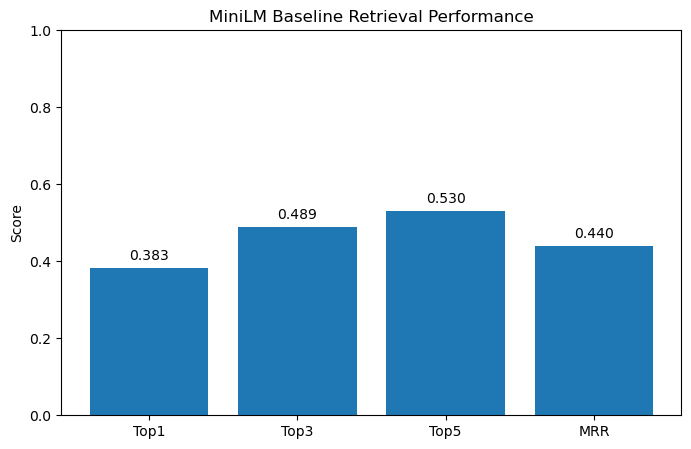

In [81]:
# [11.1] Plot Top-K and MRR baseline metrics

import matplotlib.pyplot as plt

metric_names = list(heldout_metrics.keys())
metric_values = list(heldout_metrics.values())

plt.figure(figsize=(8,5))

bars = plt.bar(
    metric_names,
    metric_values
)

plt.ylim(0,1)

plt.title("MiniLM Baseline Retrieval Performance")
plt.ylabel("Score")

# show values above bars
for b,v in zip(bars, metric_values):
    plt.text(
        b.get_x()+b.get_width()/2,
        v+0.02,
        f"{v:.3f}",
        ha="center"
    )

plt.show()

## 11.2 Performance by Query Type

Compare retrieval performance separately for:

- canonical idiom queries  
- example sentence queries

This helps identify where improvements like hybrid retrieval and reranking may help most.

In [82]:
# [11.2] Evaluate by query type

from tqdm.auto import tqdm

def evaluate_subset(df_subset):

    top1=top3=top5=0
    mrr=[]

    for _, row in tqdm(
        df_subset.iterrows(),
        total=len(df_subset),
        desc="Evaluating subset"
    ):

        preds = eval_search(
            row["input_text"],
            top_k=5
        )

        gold = row["idiom_canonical"]

        if gold in preds[:1]:
            top1 += 1

        if gold in preds[:3]:
            top3 += 1

        if gold in preds[:5]:
            top5 += 1

        mrr.append(
            reciprocal_rank(preds,gold)
        )

    return {
        "Top1": top1/len(df_subset),
        "Top3": top3/len(df_subset),
        "Top5": top5/len(df_subset),
        "MRR": np.mean(mrr)
    }


# canonical queries
df_eval_canonical = df_retrieval_bank[
    df_retrieval_bank["input_type"]=="canonical"
].sample(
    n=1000,
    random_state=42
)

# example queries
df_eval_example = df_eval.sample(
    n=1000,
    random_state=42
)

metrics_canonical = evaluate_subset(
    df_eval_canonical
)

metrics_example = evaluate_subset(
    df_eval_example
)

print("Canonical:", metrics_canonical)
print("Example:", metrics_example)

Evaluating subset:   0%|          | 0/1000 [00:00<?, ?it/s]

Evaluating subset:   0%|          | 0/1000 [00:00<?, ?it/s]

Canonical: {'Top1': 1.0, 'Top3': 1.0, 'Top5': 1.0, 'MRR': 1.0}
Example: {'Top1': 0.355, 'Top3': 0.462, 'Top5': 0.501, 'MRR': 0.41123333333333334}


## 11.3 Compare Performance by Query Type

Visualize the performance gap between direct idiom lookup and example-based semantic retrieval.

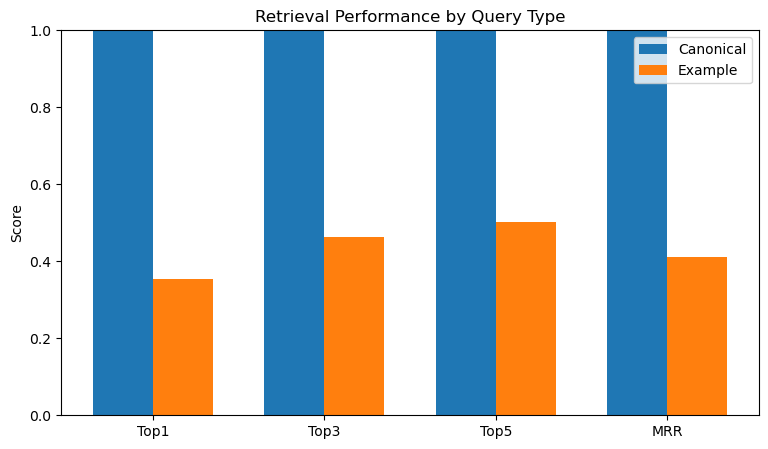

In [83]:
# [11.3] Compare query type performance

metrics = ["Top1","Top3","Top5","MRR"]

canonical_scores = [
    metrics_canonical[m]
    for m in metrics
]

example_scores = [
    metrics_example[m]
    for m in metrics
]

import numpy as np
import matplotlib.pyplot as plt

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(9,5))

plt.bar(
    x - width/2,
    canonical_scores,
    width,
    label="Canonical"
)

plt.bar(
    x + width/2,
    example_scores,
    width,
    label="Example"
)

plt.xticks(
    x,
    metrics
)

plt.ylim(0,1)

plt.title(
    "Retrieval Performance by Query Type"
)

plt.ylabel("Score")
plt.legend()

plt.show()

## Interpretation

The comparison shows a clear distinction between two retrieval modes:

- **Canonical idiom lookup** achieves near-perfect performance because it behaves largely as a deterministic lexical lookup task when the idiom itself is provided.

- **Example-based retrieval** is substantially more challenging and represents the primary semantic retrieval task of this benchmark.

Because canonical lookup is effectively solved, subsequent improvements will focus on **example-based retrieval**, where there is significant room for improvement.

### Planned Retrieval Progression
The next experiments will evaluate:

1. Dense baseline (MiniLM) ✓  
2. Hybrid retrieval (Dense + BM25)  
3. Cross-encoder reranking  
4. Optional retriever fine-tuning

This progression mirrors the retrieval strategy used in Task 2 and will be used as the main benchmark track for this task.

> Direct idiom lookup was found to be nearly deterministic, achieving near-perfect retrieval due to exact lexical matching. In contrast, example-based semantic retrieval remained substantially more challenging (Top-1 35.5%, Top-5 50.1%), motivating a staged retrieval pipeline with hybrid retrieval and reranking, following the progression used in Task 2.

## 12. Hybrid Retrieval (Dense + BM25)

Combine semantic retrieval (MiniLM) with lexical retrieval (BM25).

Dense retrieval captures semantic similarity, while BM25 can improve exact phrase and keyword matching.

In [84]:
# [12.1] Install/import BM25 package if needed

import sys
import subprocess

try:
    from rank_bm25 import BM25Okapi
except ImportError:
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "rank_bm25"]
    )
    from rank_bm25 import BM25Okapi

print("BM25 ready")

BM25 ready


In [85]:
# [12.2] Build BM25 corpus from index bank

# simple whitespace tokenization
bm25_corpus_tokens = [
    str(x).lower().split()
    for x in df_index_bank["input_text"]
]

bm25_index = BM25Okapi(
    bm25_corpus_tokens
)

print("BM25 corpus size:", len(bm25_corpus_tokens))

BM25 corpus size: 55899


## 12.3 Hybrid Search with Phrase Boost

Hybrid retrieval combines:

- Dense semantic retrieval (MiniLM)
- Lexical retrieval (BM25)
- Phrase-match boost to prioritize the intended idiom when it appears in the query

This reduces lexical bias from BM25 alone (for example *tea party* vs *spill the tea*).

In [134]:
# [12.3] Hybrid retrieval with phrase boost

def minmax_normalize(scores):
    # Normalize scores to range 0..1
    scores = np.array(scores, dtype=float)

    if scores.max() == scores.min():
        return np.zeros_like(scores)

    return (
        (scores - scores.min()) /
        (scores.max() - scores.min())
    )


def hybrid_search(
    query,
    top_k=5,
    fetch_k=50,
    dense_weight=0.8
):
    # Encode query for dense retrieval
    q_emb = retrieval_model_minilm.encode(
        [query],
        convert_to_numpy=True
    ).astype("float32")

    faiss.normalize_L2(q_emb)

    # Dense retrieval
    dense_scores, dense_indices = eval_faiss_index.search(
        q_emb,
        fetch_k
    )

    # BM25 retrieval
    query_tokens = str(query).lower().split()

    bm25_scores_all = bm25_index.get_scores(
        query_tokens
    )

    bm25_indices = np.argsort(
        bm25_scores_all
    )[::-1][:fetch_k]

    # Union candidate pool
    candidate_indices = list(
        set(dense_indices[0].tolist()) |
        set(bm25_indices.tolist())
    )

    candidates = df_index_bank.iloc[
        candidate_indices
    ].copy()

    # Dense score mapping
    dense_map = {
        idx:score
        for idx,score in zip(
            dense_indices[0],
            dense_scores[0]
        )
    }

    candidates["dense_score"] = [
        dense_map.get(i,0)
        for i in candidate_indices
    ]

    # BM25 scores
    candidates["bm25_score"] = [
        bm25_scores_all[i]
        for i in candidate_indices
    ]

    # Normalize scores
    candidates["dense_norm"] = minmax_normalize(
        candidates["dense_score"]
    )

    candidates["bm25_norm"] = minmax_normalize(
        candidates["bm25_score"]
    )

    # Hybrid weighted fusion
    candidates["hybrid_score"] = (
        dense_weight *
        candidates["dense_norm"]
        +
        (1-dense_weight) *
        candidates["bm25_norm"]
    )

    # Strict idiom phrase boost
    candidates["phrase_match_score"] = (
        candidates["idiom_canonical"]
        .apply(
            lambda x: adjacent_phrase_score(
                x,
                query
            )
        )
    )

    candidates["phrase_boost"] = (
        candidates["phrase_match_score"]
        .apply(
            lambda x: 0.20 if x==1 else 0.0
        )
    )

    # Final ranking score
    candidates["ranking_score"] = (
        candidates["hybrid_score"] +
        candidates["phrase_boost"]
    )

    # One best row per idiom
    candidates = (
        candidates
        .sort_values(
            "ranking_score",
            ascending=False
        )
        .drop_duplicates(
            "idiom_canonical"
        )
        .head(top_k)
    )

    return candidates[
        [
            "ranking_score",
            "hybrid_score",
            "phrase_boost",
            "idiom_canonical",
            "input_type",
            "input_text",

            # Canonical meanings
            "idiom_canonical_meaning",
            "idiom_canonical_meaning_arabic",
            "idiom_canonical_meaning_french",

            # Example-level meanings
            "idiom_in_example_meaning_en",
            "idiom_in_example_meaning_arabic",
            "idiom_in_example_meaning_french",

            # Explanations
            "explanation_en",
            "explanation_ar",
            "explanation_fr"
        ]
    ]

In [135]:
# [12.4] Test updated hybrid retrieval

hybrid_search(
    "She spilled the tea about the party",
    top_k=5
)

,ranking_score,hybrid_score,phrase_boost,idiom_canonical,input_type,input_text,idiom_canonical_meaning,idiom_canonical_meaning_arabic,idiom_canonical_meaning_french,idiom_in_example_meaning_en,idiom_in_example_meaning_arabic,idiom_in_example_meaning_french,explanation_en,explanation_ar,explanation_fr
10814,1.140299,0.940299,0.2,spill the tea,canonical,spill the tea,"To disclose or reveal gossip or personal, ofte...",كشف أو إفشاء الشائعات أو المعلومات الشخصية، غا...,Révéler des potins ou des informations personn...,NaN,NaN,NaN,NaN,NaN,NaN
11551,1.000000,1.000000,0.0,tea party,canonical,tea party,An event or interaction characterized by polit...,حدث أو تفاعل يتسم باللباقة والتهذيب وتجنب الصر...,None,NaN,NaN,NaN,NaN,NaN,NaN
20009,0.925970,0.925970,0.0,be mother,example,She offered to be mother and pour the tea whil...,"To serve tea or pour tea for others, often in ...",صبّ الشاي للآخرين، غالبًا في سياق الضيافة.,None,Figurative use indicating taking on the role o...,استخدام مجازي يعني القيام بدور تقديم الشاي للآ...,None,The phrase is used figuratively to describe se...,استخدم التعبير مجازيًا لوصف تقديم الشاي بأسلوب...,None
55707,0.816347,0.816347,0.0,sleep with,example,Who did she sleep with at the party last night?,To engage in sexual intercourse with someone.,ممارسة الجماع الجنسي مع شخص ما.,None,Asking about her sexual partner at the party.,سؤال عن شريكها الجنسي في الحفلة.,None,Question using the idiomatic meaning referring...,سؤال باستخدام المعنى الاصطلاحي للإشارة إلى الع...,None
41100,0.800368,0.800368,0.0,let slip,example,She let slip the surprise party plans during t...,To accidentally reveal a secret or confidentia...,الإفشاء عن سر أو معلومة سرية عن طريق الخطأ ودو...,None,She accidentally revealed the plans for the su...,كشفت عن خطط حفلة المفاجأة عن غير قصد.,None,This example shows unintentional disclosure of...,هذا المثال يوضح الإفصاح غير المقصود عن معلومات...,None


## 12.5 Evaluate Hybrid Retrieval

Evaluate hybrid retrieval on the held-out example benchmark and compare it against the dense MiniLM baseline.

In [90]:
# [12.5] Evaluate hybrid retrieval

from tqdm.auto import tqdm


def eval_hybrid_search(query, top_k=5):
    # Return predicted idioms only
    preds = hybrid_search(
        query,
        top_k=top_k
    )["idiom_canonical"].tolist()

    return preds


top1=top3=top5=0
mrr=[]

for _, row in tqdm(
    df_eval.iterrows(),
    total=len(df_eval),
    desc="Evaluating hybrid retrieval"
):

    preds = eval_hybrid_search(
        row["input_text"],
        top_k=5
    )

    gold = row["idiom_canonical"]

    if gold in preds[:1]:
        top1 += 1

    if gold in preds[:3]:
        top3 += 1

    if gold in preds[:5]:
        top5 += 1

    mrr.append(
        reciprocal_rank(
            preds,
            gold
        )
    )


hybrid_metrics = {
    "Top1": top1/len(df_eval),
    "Top3": top3/len(df_eval),
    "Top5": top5/len(df_eval),
    "MRR": np.mean(mrr)
}

hybrid_metrics

Evaluating hybrid retrieval:   0%|          | 0/11619 [00:00<?, ?it/s]

{'Top1': 0.6589207332816938,
 'Top3': 0.7099578276960151,
 'Top5': 0.7141750580945004,
 'MRR': 0.6836804659035488}

## 12.6 Compare Dense vs Hybrid Retrieval

Compare MiniLM dense retrieval with hybrid retrieval (MiniLM + BM25 + phrase boost).

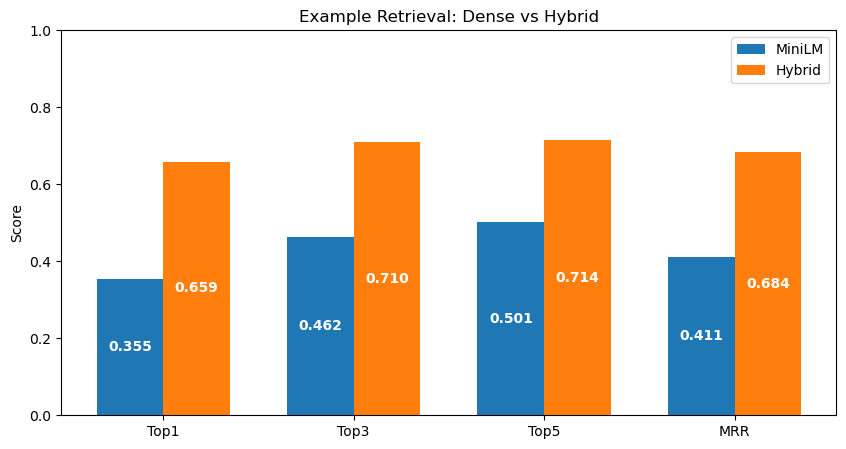

In [92]:
# [12.6] Compare baseline vs hybrid with values on bars

metrics = ["Top1","Top3","Top5","MRR"]

baseline_scores = [
    metrics_example[m]
    for m in metrics
]

hybrid_scores = [
    hybrid_metrics[m]
    for m in metrics
]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(10,5))

bars1 = plt.bar(
    x-width/2,
    baseline_scores,
    width,
    label="MiniLM"
)

bars2 = plt.bar(
    x+width/2,
    hybrid_scores,
    width,
    label="Hybrid"
)

plt.xticks(
    x,
    metrics
)

plt.ylim(0,1)

plt.title(
    "Example Retrieval: Dense vs Hybrid"
)

plt.ylabel("Score")
plt.legend()


# Add values inside bars
for bars in [bars1, bars2]:
    for b in bars:
        h = b.get_height()

        plt.text(
            b.get_x()+b.get_width()/2,
            h/2,                # inside bar
            f"{h:.3f}",
            ha="center",
            va="center",
            color="white",
            fontweight="bold"
        )

plt.show()

## Hybrid Retrieval Results

Hybrid retrieval substantially improves semantic idiom meaning retrieval over dense retrieval alone.

Observed gains:

- Top-1: 35.5% → 65.9%
- Top-3: 46.2% → 71.0%
- Top-5: 50.1% → 71.4%
- MRR: 41.1% → 68.4%

These results show that combining semantic retrieval, lexical retrieval, and phrase-aware ranking significantly improves example-based idiom meaning retrieval.

## 13. Cross-Encoder Reranking

Use a cross-encoder reranker to rescore top candidates returned by hybrid retrieval.

Unlike embedding similarity, the reranker jointly reads the query and candidate text, which can improve Top-1 ranking.

In [93]:
# [13.1] Load reranker model

import sys
import subprocess

try:
    from sentence_transformers import CrossEncoder
except ImportError:
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "sentence-transformers"]
    )
    from sentence_transformers import CrossEncoder


RERANKER_MODEL = "cross-encoder/ms-marco-MiniLM-L-6-v2"

reranker_ce = CrossEncoder(
    RERANKER_MODEL
)

print("Reranker loaded:", RERANKER_MODEL)

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: cross-encoder/ms-marco-MiniLM-L-6-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Reranker loaded: cross-encoder/ms-marco-MiniLM-L-6-v2


In [138]:
# [13.2] Hybrid retrieval + reranking

def hybrid_rerank_search(
    query,
    top_k=5,
    retrieve_k=20
):
    # First retrieve candidates from hybrid search
    candidates = hybrid_search(
        query,
        top_k=retrieve_k
    ).copy()

    # Build query-candidate pairs
    pairs = []

    for _, row in candidates.iterrows():

        candidate_text = (
            str(row["idiom_canonical"]) +
            " | " +
            str(row["idiom_canonical_meaning"])
        )

        pairs.append(
            (query, candidate_text)
        )

    # Cross-encoder reranking scores
    rerank_scores = reranker_ce.predict(
        pairs
    )

    candidates["rerank_score"] = rerank_scores

    # Sort by reranker
    candidates = (
        candidates
        .sort_values(
            "rerank_score",
            ascending=False
        )
        .head(top_k)
    )

    return candidates[
        [
            "ranking_score",
            "hybrid_score",
            "phrase_boost",
            "idiom_canonical",
            "input_type",
            "input_text",

            # Canonical meanings
            "idiom_canonical_meaning",
            "idiom_canonical_meaning_arabic",
            "idiom_canonical_meaning_french",

            # Example-level meanings
            "idiom_in_example_meaning_en",
            "idiom_in_example_meaning_arabic",
            "idiom_in_example_meaning_french",

            # Explanations
            "explanation_en",
            "explanation_ar",
            "explanation_fr"
        ]
    ]

In [139]:
# [13.3] Test reranking

hybrid_rerank_search(
    "She spilled the tea about the party",
    top_k=5
)

,ranking_score,hybrid_score,phrase_boost,idiom_canonical,input_type,input_text,idiom_canonical_meaning,idiom_canonical_meaning_arabic,idiom_canonical_meaning_french,idiom_in_example_meaning_en,idiom_in_example_meaning_arabic,idiom_in_example_meaning_french,explanation_en,explanation_ar,explanation_fr
10814,1.140299,0.940299,0.2,spill the tea,canonical,spill the tea,"To disclose or reveal gossip or personal, ofte...",كشف أو إفشاء الشائعات أو المعلومات الشخصية، غا...,Révéler des potins ou des informations personn...,NaN,NaN,NaN,NaN,NaN,NaN
11551,1.000000,1.000000,0.0,tea party,canonical,tea party,An event or interaction characterized by polit...,حدث أو تفاعل يتسم باللباقة والتهذيب وتجنب الصر...,None,NaN,NaN,NaN,NaN,NaN,NaN
24863,0.792177,0.792177,0.0,clock the tea,example,How did you clock the tea so quickly about the...,To notice or discover the truth or hidden fact...,ملاحظة أو اكتشاف الحقيقة أو الحقائق الخفية، وخ...,None,How did you find out the secret truth about th...,كيف اكتشفت الحقيقة السرية عن انفصالهم بسرعة؟,None,Figurative question about rapidly discovering ...,سؤال مجازي حول اكتشاف النميمة أو الحقيقة بسرعة.,None
942,0.715307,0.715307,0.0,all the tea in China,canonical,all the tea in China,Something extremely valuable or of great worth...,شيء ذو قيمة كبيرة جداً أو غالي لا يمكن استبدال...,None,NaN,NaN,NaN,NaN,NaN,NaN
20009,0.925970,0.925970,0.0,be mother,example,She offered to be mother and pour the tea whil...,"To serve tea or pour tea for others, often in ...",صبّ الشاي للآخرين، غالبًا في سياق الضيافة.,None,Figurative use indicating taking on the role o...,استخدام مجازي يعني القيام بدور تقديم الشاي للآ...,None,The phrase is used figuratively to describe se...,استخدم التعبير مجازيًا لوصف تقديم الشاي بأسلوب...,None


## 13.4 Evaluate Hybrid + Reranker

Evaluate whether reranking improves held-out example retrieval beyond hybrid retrieval alone.

In [96]:
# [13.4] Evaluation search using reranker

def eval_rerank_search(
    query,
    top_k=5
):
    preds = hybrid_rerank_search(
        query,
        top_k=top_k
    )["idiom_canonical"].tolist()

    return preds

In [97]:
# [13.5] Evaluate reranked retrieval

from tqdm.auto import tqdm

top1=top3=top5=0
mrr=[]

for _, row in tqdm(
    df_eval.iterrows(),
    total=len(df_eval),
    desc="Evaluating reranker"
):

    preds = eval_rerank_search(
        row["input_text"],
        top_k=5
    )

    gold = row["idiom_canonical"]

    if gold in preds[:1]:
        top1 += 1

    if gold in preds[:3]:
        top3 += 1

    if gold in preds[:5]:
        top5 += 1

    mrr.append(
        reciprocal_rank(
            preds,
            gold
        )
    )


rerank_metrics = {
    "Top1": top1/len(df_eval),
    "Top3": top3/len(df_eval),
    "Top5": top5/len(df_eval),
    "MRR": np.mean(mrr)
}

rerank_metrics

Evaluating reranker:   0%|          | 0/11619 [00:00<?, ?it/s]

{'Top1': 0.6741544022721404,
 'Top3': 0.7126258714175058,
 'Top5': 0.7160685084774938,
 'MRR': 0.6930731273488826}

## 14. Final Model Comparison

Compare retrieval performance across all retrieval stages:

- Dense MiniLM baseline  
- Hybrid retrieval  
- Hybrid + reranking

In [98]:
# [14.1] Final metrics table

results_table = pd.DataFrame({
    "Metric": ["Top1","Top3","Top5","MRR"],
    "MiniLM": [
        metrics_example["Top1"],
        metrics_example["Top3"],
        metrics_example["Top5"],
        metrics_example["MRR"]
    ],
    "Hybrid": [
        hybrid_metrics["Top1"],
        hybrid_metrics["Top3"],
        hybrid_metrics["Top5"],
        hybrid_metrics["MRR"]
    ],
    "Hybrid+Rerank": [
        rerank_metrics["Top1"],
        rerank_metrics["Top3"],
        rerank_metrics["Top5"],
        rerank_metrics["MRR"]
    ]
})

results_table

,Metric,MiniLM,Hybrid,Hybrid+Rerank
0,Top1,0.355000,0.658921,0.674154
1,Top3,0.462000,0.709958,0.712626
2,Top5,0.501000,0.714175,0.716069
3,MRR,0.411233,0.683680,0.693073


## 14.2 Retrieval Performance Progression

Visualize performance gains across dense retrieval, hybrid retrieval, and reranking.

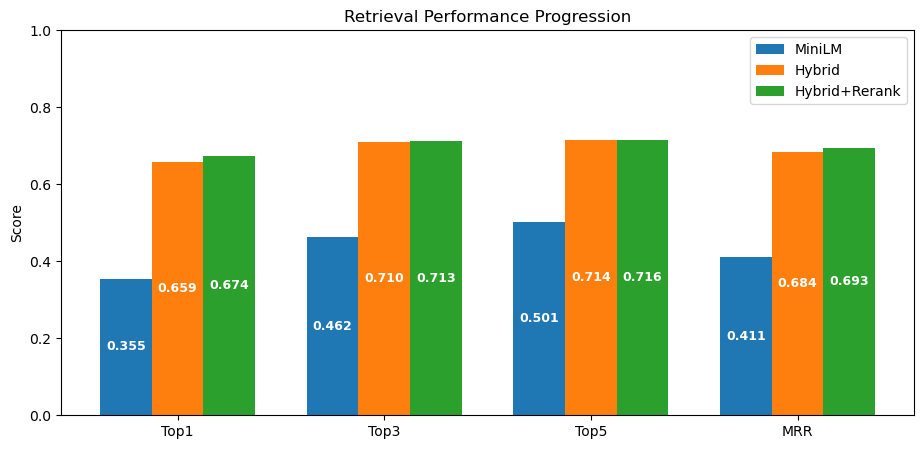

In [99]:
# [14.2] Three-model comparison chart

metrics = ["Top1","Top3","Top5","MRR"]

m1 = results_table["MiniLM"].values
m2 = results_table["Hybrid"].values
m3 = results_table["Hybrid+Rerank"].values

x = np.arange(len(metrics))
width = 0.25

plt.figure(figsize=(11,5))

bars1 = plt.bar(
    x-width,
    m1,
    width,
    label="MiniLM"
)

bars2 = plt.bar(
    x,
    m2,
    width,
    label="Hybrid"
)

bars3 = plt.bar(
    x+width,
    m3,
    width,
    label="Hybrid+Rerank"
)

plt.xticks(
    x,
    metrics
)

plt.ylim(0,1)

plt.title(
    "Retrieval Performance Progression"
)

plt.ylabel("Score")
plt.legend()


# Add values inside bars
for bars in [bars1,bars2,bars3]:

    for b in bars:

        h = b.get_height()

        plt.text(
            b.get_x()+b.get_width()/2,
            h/2,
            f"{h:.3f}",
            ha="center",
            va="center",
            color="white",
            fontweight="bold",
            fontsize=9
        )

plt.show()

## 14.3 Top-K Retrieval Curves

Measure retrieval accuracy as K increases, showing how quickly each model retrieves the correct idiom.

In [101]:
# [14.3] Fast Top-K curves (single pass)

K_VALUES = list(range(1,11))


def compute_topk_curve(search_fn):

    correct_at_k = np.zeros(len(K_VALUES))

    for _, row in tqdm(
        df_eval.iterrows(),
        total=len(df_eval),
        desc="Computing Top-K"
    ):

        preds = search_fn(
            row["input_text"],
            top_k=max(K_VALUES)
        )

        gold = row["idiom_canonical"]

        for i,k in enumerate(K_VALUES):

            if gold in preds[:k]:
                correct_at_k[i] += 1

    return (
        correct_at_k /
        len(df_eval)
    )


baseline_curve = compute_topk_curve(
    eval_search
)

hybrid_curve = compute_topk_curve(
    eval_hybrid_search
)

rerank_curve = compute_topk_curve(
    eval_rerank_search
)

Computing Top-K:   0%|          | 0/11619 [00:00<?, ?it/s]

Computing Top-K:   0%|          | 0/11619 [00:00<?, ?it/s]

Computing Top-K:   0%|          | 0/11619 [00:00<?, ?it/s]

## 14.4 Save Top-K Curve Results

Save the computed Top-K curve values so the plot can be regenerated later without rerunning the long evaluation.

In [160]:
# [14.4] Save Top-K curve results

topk_results = pd.DataFrame({
    "K": K_VALUES,
    "MiniLM": baseline_curve,
    "Hybrid": hybrid_curve,
    "Hybrid_Rerank": rerank_curve
})

topk_path = f"{ARTIFACT_TASK4_DIR}/topk_curve_results.csv"

topk_results.to_csv(
    topk_path,
    index=False
)

print("Saved:", topk_path)

topk_results

Saved: ../artifacts/task4/topk_curve_results.csv


,K,MiniLM,Hybrid,Hybrid_Rerank
0,1,0.383166,0.658921,0.674154
1,2,0.454944,0.699544,0.705999
2,3,0.489371,0.709958,0.712626
3,4,0.512350,0.712626,0.714605
4,5,0.530338,0.714175,0.716069
5,6,0.545916,0.714691,0.716499
6,7,0.556158,0.715380,0.716929
7,8,0.568121,0.715724,0.716929
8,9,0.577847,0.716155,0.717187
9,10,0.585506,0.716585,0.717187


## 14.5 Top-K Retrieval Curves

Visualize how retrieval accuracy changes as K increases for all models.

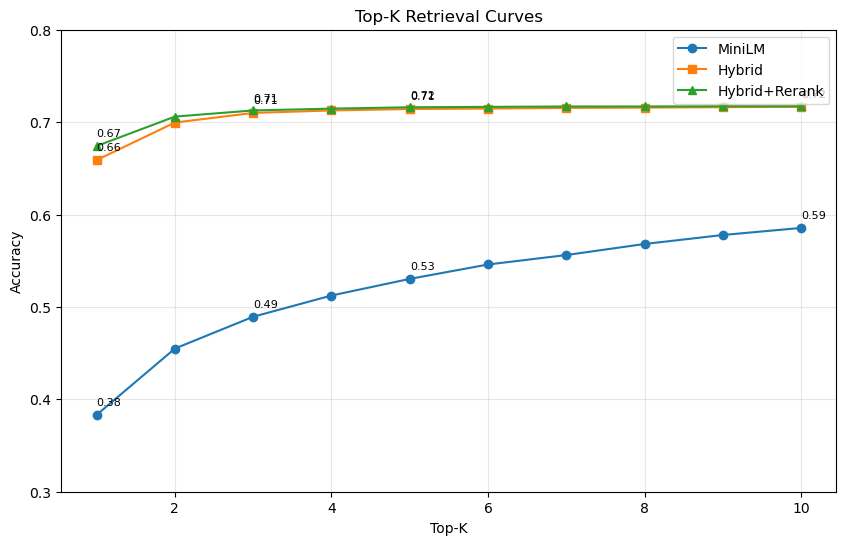

In [103]:
# [14.5] Plot Top-K retrieval curves

plt.figure(figsize=(10,6))

plt.plot(
    topk_results["K"],
    topk_results["MiniLM"],
    marker="o",
    label="MiniLM"
)

plt.plot(
    topk_results["K"],
    topk_results["Hybrid"],
    marker="s",
    label="Hybrid"
)

plt.plot(
    topk_results["K"],
    topk_results["Hybrid_Rerank"],
    marker="^",
    label="Hybrid+Rerank"
)

# add value labels at selected K
for model_col in [
    "MiniLM",
    "Hybrid",
    "Hybrid_Rerank"
]:
    for i,row in topk_results.iterrows():

        if row["K"] in [1,3,5,10]:

            plt.text(
                row["K"],
                row[model_col]+0.01,
                f"{row[model_col]:.2f}",
                fontsize=8
            )

plt.xlabel("Top-K")
plt.ylabel("Accuracy")
plt.title("Top-K Retrieval Curves")
plt.ylim(0.3,0.8)

plt.grid(True, alpha=0.3)
plt.legend()

plt.show()

## Top-K Curve Interpretation

Key observations:

- Dense retrieval improves gradually as K increases.

- Hybrid retrieval produces large gains already at low K (especially Top-1 to Top-3), indicating much stronger early ranking quality.

- Hybrid and reranked retrieval largely saturate around **K=5**, suggesting most relevant idioms are retrieved within a very small candidate set.

- Reranking provides modest but consistent gains mainly at lower K, improving precision at the top of the ranking.

## 15. Error Analysis and Failure Modes

Analyze retrieval failures to understand where the model struggles and what types of errors remain.

In [105]:
# [15.1] Collect Top-1 failures (sampled error analysis)

ERROR_SAMPLE_N = 1000

df_error_eval = df_eval.sample(
    n=ERROR_SAMPLE_N,
    random_state=42
).reset_index(drop=True)


failure_cases = []

for _, row in tqdm(
    df_error_eval.iterrows(),
    total=len(df_error_eval),
    desc="Collecting failures"
):

    preds = eval_rerank_search(
        row["input_text"],
        top_k=1
    )

    predicted = preds[0]
    gold = row["idiom_canonical"]

    if predicted != gold:

        failure_cases.append({
            "query": row["input_text"],
            "gold_idiom": gold,
            "predicted_idiom": predicted
        })


df_failures = pd.DataFrame(
    failure_cases
)

print(
    "Sample failures:",
    len(df_failures)
)

df_failures.head(10)

Sample failures: 364


,query,gold_idiom,predicted_idiom
0,Is my answer on the nose regarding the client’...,on the nose,do the needful
1,The manager was noticeably lathered up over th...,lathered up,you're good
2,Can someone please take me through the new upd...,take me through,out to sea
3,How hard did the team whomp on their rivals in...,whomp on,hard as nails
4,"After months of setbacks, her career took off ...",smooth sailing,take time off
5,"She asked herself, 'What the hell am I doing w...",what the hell,how's life
6,"When you need help, your girl is always there.",your girl,do you need help
7,"Just ate 10 burgers or so, feeling stuffed! #f...",or so,stuffed like a turkey
8,The two companies merged in 2015; the rest is ...,the rest is history,to date
9,"The manager was otherwise engaged, reviewing t...",otherwise engaged,in the first place


## 15.2 Failure Mode Categorization

Manually categorize representative retrieval failures into common error types.

In [106]:
# [15.2] Simple manual-style failure type heuristics

def classify_failure(row):

    gold = str(row["gold_idiom"]).lower()
    pred = str(row["predicted_idiom"]).lower()

    gold_words = set(gold.split())
    pred_words = set(pred.split())

    overlap = len(
        gold_words.intersection(
            pred_words
        )
    )

    # lexical overlap confusion
    if overlap > 0:
        return "Lexical Confusion"

    # both short idioms often ambiguous
    if len(gold_words) <=3 and len(pred_words)<=3:
        return "Short/Ambiguous Idioms"

    # default semantic confusion
    return "Semantic Confusion"


df_failures["failure_type"] = (
    df_failures
    .apply(
        classify_failure,
        axis=1
    )
)

failure_summary = (
    df_failures["failure_type"]
    .value_counts()
    .reset_index()
)

failure_summary.columns = [
    "Failure_Type",
    "Count"
]

failure_summary

,Failure_Type,Count
0,Short/Ambiguous Idioms,137
1,Lexical Confusion,120
2,Semantic Confusion,107


## 15.3 Failure Mode Distribution

Visualize the dominant sources of retrieval errors.

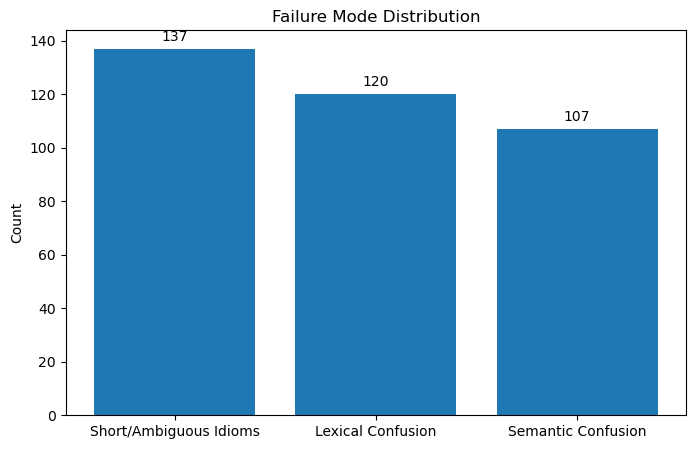

In [107]:
# [15.3] Plot failure mode distribution

plt.figure(figsize=(8,5))

bars = plt.bar(
    failure_summary["Failure_Type"],
    failure_summary["Count"]
)

plt.title(
    "Failure Mode Distribution"
)

plt.ylabel("Count")

# values above bars
for b,v in zip(
    bars,
    failure_summary["Count"]
):
    plt.text(
        b.get_x()+b.get_width()/2,
        v+3,
        str(v),
        ha="center"
    )

plt.show()

## Failure Analysis Summary

The dominant remaining errors fall into three categories:

- **Short or ambiguous idioms**, where limited lexical context makes disambiguation difficult.

- **Lexical confusion**, where the system retrieves a surface-similar but incorrect idiom.

- **Semantic confusion**, where retrieved idioms are meaning-related but incorrect.

These failure patterns suggest future gains may come more from contextual disambiguation and retriever fine-tuning than lexical retrieval improvements alone.

## 16. Qualitative Retrieval Examples

Inspect representative successful and failed retrieval cases.

In [109]:
# [16.1] Representative failure examples

df_failures.sample(
    5,
    random_state=42
)[[
    "query",
    "gold_idiom",
    "predicted_idiom",
    "failure_type"
]]

,query,gold_idiom,predicted_idiom,failure_type
193,The new movement promises to sweep away inequa...,sweep away,break the wheel,Short/Ambiguous Idioms
33,The report refused point-blank to support the ...,point-blank,say no more,Short/Ambiguous Idioms
15,What's the haps with the project deadline?,what's the haps,get it on,Short/Ambiguous Idioms
347,"Oh sure, just get a fix of work by doing liter...",get a fix,day or night,Short/Ambiguous Idioms
57,"Oh great, another email right before closing—w...",race against time,time thief,Lexical Confusion


### Qualitative Observations

Successful retrievals are strongest when:
- the idiomatic signal is explicit
- contextual clues are rich
- lexical ambiguity is low

Failures often occur when:
- idioms are short or highly ambiguous
- competing idioms share lexical overlap
- context is sparse or noisy

## 16.2 Retrieval Success vs Failure

Summarize overall Top-1 retrieval success and failure rates.

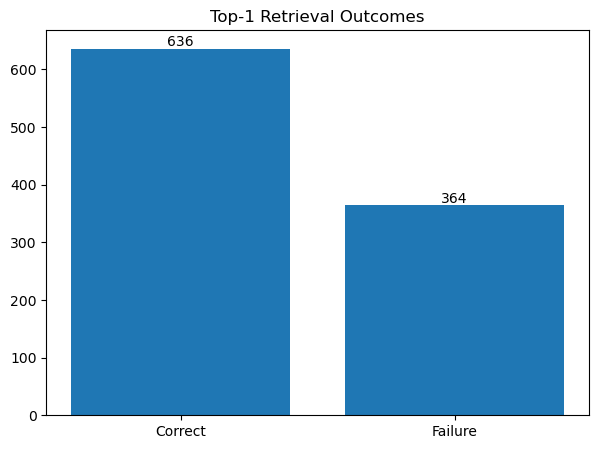

Success Rate: 0.636


In [110]:
# [16.2] Success vs failure rates

success_count = len(df_error_eval) - len(df_failures)
failure_count = len(df_failures)

labels = [
    "Correct",
    "Failure"
]

values = [
    success_count,
    failure_count
]

plt.figure(figsize=(7,5))

bars = plt.bar(
    labels,
    values
)

plt.title(
    "Top-1 Retrieval Outcomes"
)

for b,v in zip(bars, values):
    plt.text(
        b.get_x()+b.get_width()/2,
        v+5,
        str(v),
        ha="center"
    )

plt.show()

print(
    f"Success Rate: {success_count/len(df_error_eval):.3f}"
)

## 17. Interactive Demo (Notebook Prototype)

Small interactive prototype using the final Hybrid + Reranker retrieval system.

In [143]:
# [17.1] Final demo function with multilingual output

def idiomx_demo(query, top_k=3):

    # Use the final production pipeline
    results = hybrid_rerank_search(
        query,
        top_k=top_k
    )

    print("\nQuery:", query)
    print("=" * 90)

    for rank, (_, row) in enumerate(results.iterrows(), start=1):

        print(f"\nRank {rank}")
        print("-" * 90)

        # Idiom
        print("Idiom:")
        print(row["idiom_canonical"])

        # English meaning
        print("\nMeaning (EN):")
        print(row["idiom_canonical_meaning"])

        # Arabic meaning
        if "idiom_canonical_meaning_arabic" in row and pd.notna(row["idiom_canonical_meaning_arabic"]):
            print("\nMeaning (AR):")
            print(row["idiom_canonical_meaning_arabic"])

        # French meaning if available
        if "idiom_canonical_meaning_french" in row and pd.notna(row["idiom_canonical_meaning_french"]):
            print("\nMeaning (FR):")
            print(row["idiom_canonical_meaning_french"])

        # Reranker score if available
        if "rerank_score" in row:
            print(
                "\nRerank Score:",
                round(row["rerank_score"], 4)
            )

    print("\n" + "=" * 90)

In [144]:
row

idiom_canonical                                                stuffed like a turkey
idiom_canonical_meaning            Extremely full or bloated from eating too much...
idiom_canonical_meaning_arabic     شَعور شديد بالامتلاء أو الانتفاخ بسبب الأكل ال...
idiom_canonical_meaning_french                                                   NaN
idiom_level_explanation_en         The phrase uses the image of a turkey stuffed ...
idiom_level_explanation_ar         تستخدم العبارة صورة الديك الرومي المحشو بالطعا...
idiom_level_explanation_fr                                                       NaN
example                            Why do I always feel stuffed like a turkey aft...
semantic_quality                                                              medium
validation_status                                                              valid
input_text                         Why do I always feel stuffed like a turkey aft...
input_type                                                       

In [145]:
# [17.2] Example demo queries

idiomx_demo(
    "She spilled the tea about the party"
)

idiomx_demo(
    "He finally broke the ice in the meeting"
)

idiomx_demo(
    "That idea came out of left field"
)


Query: She spilled the tea about the party

Rank 1
------------------------------------------------------------------------------------------
Idiom:
spill the tea

Meaning (EN):
To disclose or reveal gossip or personal, often secret, information about someone.

Meaning (AR):
كشف أو إفشاء الشائعات أو المعلومات الشخصية، غالبًا السرية، عن شخص ما.

Meaning (FR):
Révéler des potins ou des informations personnelles, souvent secrètes, sur quelqu’un.

Rank 2
------------------------------------------------------------------------------------------
Idiom:
tea party

Meaning (EN):
An event or interaction characterized by politeness, civility, and avoidance of conflict, typically implying a delicate or overly courteous atmosphere.

Meaning (AR):
حدث أو تفاعل يتسم باللباقة والتهذيب وتجنب الصراع، وعادة ما يشير إلى جو دقيق أو مجامل للغاية.

Rank 3
------------------------------------------------------------------------------------------
Idiom:
clock the tea

Meaning (EN):
To notice or discover the 

In [146]:
# [17.3] Interactive loop (type quit to stop)

while True:

    q = input(
        "\nEnter idiom sentence (or quit): "
    )

    if q.lower()=="quit":
        break

    idiomx_demo(q)


Enter idiom sentence (or quit): he spill the bean

Query: he spill the bean

Rank 1
------------------------------------------------------------------------------------------
Idiom:
spill the beans

Meaning (EN):
To reveal secret or confidential information, often unintentionally or prematurely.

Meaning (AR):
كشف معلومات سرية أو خاصة، غالبًا بدون قصد أو قبل الوقت المناسب.

Meaning (FR):
Révéler des informations secrètes ou confidentielles, souvent involontairement ou prématurément.

Rank 2
------------------------------------------------------------------------------------------
Idiom:
spill the tea

Meaning (EN):
To disclose or reveal gossip or personal, often secret, information about someone.

Meaning (AR):
كشف أو إفشاء الشائعات أو المعلومات الشخصية، غالبًا السرية، عن شخص ما.

Meaning (FR):
Révéler des potins ou des informations personnelles, souvent secrètes, sur quelqu’un.

Rank 3
------------------------------------------------------------------------------------------
Idiom:
s

## 19. Save Final Production Artifacts

Save the final retrieval system artifacts for reproducibility, deployment, and the separate demo notebook / Hugging Face Space.

In [147]:
# [19.1] Save benchmark metrics

import json
import os

os.makedirs(
    ARTIFACT_DIR,
    exist_ok=True
)

benchmark_results = {
    "MiniLM": metrics_example,
    "Hybrid": hybrid_metrics,
    "Hybrid_Rerank": rerank_metrics
}

with open(
    f"{ARTIFACT_TASK4_DIR}/benchmark_metrics.json",
    "w"
) as f:
    json.dump(
        benchmark_results,
        f,
        indent=2
    )

print(
    "Saved benchmark metrics"
)

Saved benchmark metrics


In [148]:
# [19.2] Save retrieval bank

df_retrieval_bank.to_parquet(
    f"{ARTIFACT_TASK4_DIR}/final_retrieval_bank.parquet",
    index=False
)

print(
    "Saved retrieval bank"
)

Saved retrieval bank


In [149]:
# [19.3] Save embeddings

np.save(
    f"{ARTIFACT_TASK4_DIR}/final_retrieval_embeddings.npy",
    retrieval_embeddings
)

print(
    "Saved embeddings"
)

Saved embeddings


In [150]:
# [19.4] Save final FAISS index

faiss.write_index(
    faiss_index_minilm,
    f"{ARTIFACT_TASK4_DIR}/final_faiss.index"
)

print(
    "Saved FAISS index"
)

Saved FAISS index


In [151]:
# [19.5] Save model configuration

model_config = {

    # Embedding retriever model used
    "embedding_model":
        "sentence-transformers/all-MiniLM-L6-v2",

    # Cross-encoder reranker model
    "reranker_model":
        RERANKER_MODEL,

    # Final selected retrieval pipeline
    "retrieval_pipeline":
        "Hybrid + CrossEncoder Reranker",

    # Recommended model for demo deployment
    "recommended_demo_model":
        "Hybrid_Rerank"

}

with open(
    f"{ARTIFACT_TASK4_DIR}/model_config.json",
    "w"
) as f:

    json.dump(
        model_config,
        f,
        indent=2
    )

print(
    "Saved model configuration"
)

Saved model configuration


In [152]:
# [19.6] Save BM25 corpus tokens

import pickle

with open(
    f"{ARTIFACT_TASK4_DIR}/bm25_corpus_tokens.pkl",
    "wb"
) as f:

    pickle.dump(
        bm25_corpus_tokens,
        f
    )

print(
    "Saved BM25 corpus tokens"
)

Saved BM25 corpus tokens


In [153]:
# [19.7] Save deployment manifest

deployment_manifest = {
    "production_pipeline":
        "Hybrid + CrossEncoder Reranker",

    "artifacts": [
        "final_retrieval_bank.parquet",
        "final_retrieval_embeddings.npy",
        "final_faiss.index",
        "bm25_corpus_tokens.pkl",
        "benchmark_metrics.json",
        "topk_curve_results.csv",
        "model_config.json"
    ]
}

with open(
    f"{ARTIFACT_TASK4_DIR}/deployment_manifest.json",
    "w"
) as f:

    json.dump(
        deployment_manifest,
        f,
        indent=2
    )

print(
    "Saved deployment manifest"
)

Saved deployment manifest


    artifacts_meaning_retrieval/
    ├── final_retrieval_bank.parquet
    ├── final_retrieval_embeddings.npy
    ├── final_faiss.index
    ├── bm25_corpus_tokens.pkl
    ├── benchmark_metrics.json
    ├── benchmark_results.csv
    ├── topk_curve_results.csv
    ├── model_config.json
    └── deployment_manifest.json

## Final Outcome

This notebook produced:

- multilingual idiom meaning retrieval benchmark  
- dense, hybrid, and reranked retrieval models  
- quantitative and qualitative evaluation  
- reusable deployment artifacts

Final recommended production system:

**Hybrid Retrieval + Cross-Encoder Reranker**